In [3]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

ModuleNotFoundError: No module named 'tensorflow'

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os

BASE_PATH = "/mnt/d/projects/thyroid_cancer_detection/archive"
DATASET_PATH = os.path.join(BASE_PATH, "Thyroid Data")

In [4]:
import os
import pandas as pd
categories = [0, 1]

image_paths = []
labels = []

for cat in categories:
    labelled_path = os.path.join(DATASET_PATH, str(cat))
    for img_name in os.listdir(labelled_path):
        if img_name.lower().endswith((".png", ".jpeg", ".jpg")):
            image_path = os.path.join(labelled_path, img_name)
            image_paths.append(image_path)
            labels.append(int(cat))

df = pd.DataFrame({"img_path" : image_paths, "label" : labels})
df.head()

,img_path,label
0,/mnt/d/projects/thyroid_cancer_detection/archi...,0
1,/mnt/d/projects/thyroid_cancer_detection/archi...,0
2,/mnt/d/projects/thyroid_cancer_detection/archi...,0
3,/mnt/d/projects/thyroid_cancer_detection/archi...,0
4,/mnt/d/projects/thyroid_cancer_detection/archi...,0


In [5]:
print(len(df))
print(df["label"].value_counts())
print(df.shape)

3115
label
0    1905
1    1210
Name: count, dtype: int64
(3115, 2)


### Data Visualization

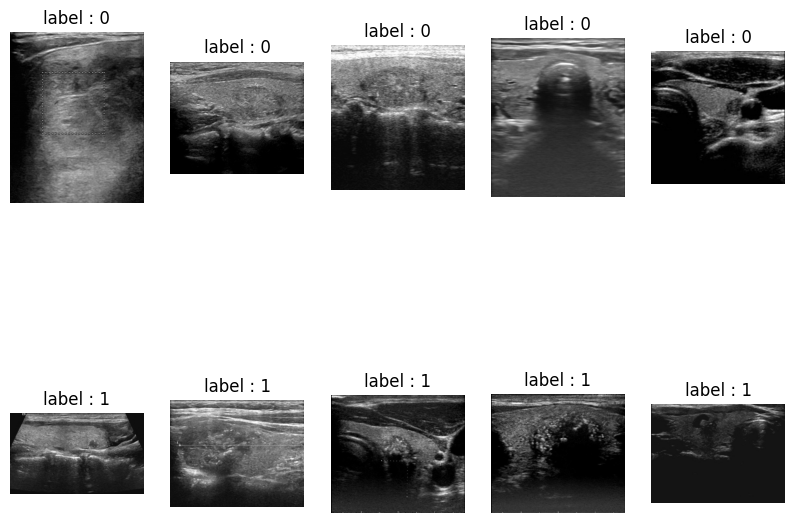

In [6]:
import cv2
import matplotlib.pyplot as plt

num_images = 5
categories = ["0", "1"]

plt.figure(figsize= (10, 8))

for i, category in enumerate(categories):
    category_int = int(category)
    category_images = df[df["label"] == category_int]["img_path"].iloc[:num_images]

    for j, image_path in enumerate(category_images):
        img = cv2.imread(image_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(categories), num_images, i * num_images + j + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"label : {category}")

        else:
            print("No Image found")

plt.tight_layout
plt.show()

### Data Augmentation

In [7]:
majority_class = df[df["label"] == 0]
minority_class = df[df["label"] == 1]

minority_oversampled = minority_class.sample(n = len(majority_class), replace= True, random_state= 42)

df_resampled = pd.concat([majority_class, minority_oversampled]).sample(frac=1, random_state= 42).reset_index(drop= True)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df_resampled["category_encoded"] = encoder.fit_transform(df_resampled["label"])

print(df_resampled['label'].value_counts())
print(df_resampled['label'].nunique())
print(len(df_resampled))

label
0    1905
1    1905
Name: count, dtype: int64
2
3810


### Model Training

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import  regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Train Test Val Split

In [9]:
train_df, temp_df = train_test_split(
    df_resampled, 
    test_size= 0.2,
    shuffle= True,
    random_state= 42,
    stratify= df_resampled["category_encoded"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size= 0.5,
    stratify= temp_df["category_encoded"],
    shuffle = True,
    random_state= 42
)

train_df["category_encoded"] = train_df["category_encoded"].astype(str)
val_df["category_encoded"] = val_df["category_encoded"].astype(str)
test_df["category_encoded"] = test_df["category_encoded"].astype(str)

print(len(train_df))
print(len(val_df))
print(len(test_df))
print(train_df["category_encoded"].dtype)

3048
381
381
str


In [10]:
batch_size = 4
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

train_gen = ImageDataGenerator(rescale= 1./255)
test_gen = ImageDataGenerator(rescale = 1./255)

train_gen_new = train_gen.flow_from_dataframe(
    train_df, 
    x_col = "img_path",
    y_col = "category_encoded",
    target_size = img_size,
    class_mode = "binary",
    color_mode = "rgb",
    shuffle = True,
    batch_size = batch_size
)
valid_gen_new = test_gen.flow_from_dataframe(
    val_df, 
    x_col = "img_path",
    y_col = "category_encoded",
    target_size = img_size,
    class_mode = "binary",
    color_mode = "rgb",
    shuffle = True,
    batch_size = batch_size
)
test_gen_new = test_gen.flow_from_dataframe(
    test_df, 
    x_col = "img_path",
    y_col = "category_encoded",
    target_size = img_size,
    class_mode = "binary",
    color_mode = "rgb",
    shuffle = False,
    batch_size = batch_size
)

Found 3048 validated image filenames belonging to 2 classes.
Found 381 validated image filenames belonging to 2 classes.
Found 381 validated image filenames belonging to 2 classes.


In [11]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is set for Tensorflow")
    except RuntimeError as e:
        print(e)

GPU is set for Tensorflow


In [12]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

### Model Training

In [ ]:
from tensorflow.keras import layers, Model

class Avg2MaxPooling(layers.Layer):
    def __init__(self, pool_size = 3, strides = 2, padding = "same"):
        super().__init__()
        self.avg_pool = layers.AveragePooling2D(pool_size, strides, padding)
        self.max_pool = layers.MaxPooling2D(pool_size, strides, padding)

    def call(self, inputs):
        return self.avg_pool(inputs) - (self.max_pool(inputs) + self.max_pool(inputs))

class DepthwiseSeparableConv(layers.Layer):
    def __init__(self, filters, kernel_size = 3, strides = 1):
        super().__init__()
        self.dw = layers.DepthwiseConv2D(kernel_size, strides, padding = "same")
        self.pw = layers.Conv2D(filters, 1, strides = 1)
        self.bn = layers.BatchNormalization()

    def call(self, inputs):
        x = self.dw(inputs)
        x = self.pw(x)
        return tf.nn.relu(self.bn(x))

def create_fibonacci_net(input_shape = (224, 224, 3), num_classes = 1):
    inputs = layers.Input(shape = input_shape)

    # Block 1
    x = layers.Conv2D(21, 3, padding= "same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 2
    x = layers.Conv2D(34, 3, padding= "same")(x)
    x = layers.BatchNormalization()(x)
    x2 = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 3
    x = layers.Conv2D(55, 3, padding= "same")(x)
    x = layers.BatchNormalization()(x)
    x3 = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    # pcb 1: Block 2 - Block 4
    pcb1 = layers.Conv2D(24, 3, padding= "same")(x2)
    pcb1 = Avg2MaxPooling()(pcb1)
    pcb1 = layers.Conv2D(24, 3, padding = "same")(pcb1)
    pcb1 = Avg2MaxPooling()(pcb1)

    #Block 4
    x = layers.Conv2D(89, 3, padding = "same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    pcb1 = layers.Resizing(14, 14)(pcb1)

    x = layers.concatenate([x, pcb1])

    pcb2 = layers.Conv2D(24, 3, padding= "same")(x3)
    pcb2 = Avg2MaxPooling()(pcb2)
    pcb2 = layers.Conv2D(24, 3, padding = "same")(pcb2)
    pcb2 = Avg2MaxPooling()(pcb2)

    # Block 5
    x = layers.Conv2D(144, 3, padding = "same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)

    pcb2 = layers.Resizing(7, 7)(pcb2)

    x = layers.concatenate([x, pcb2])

    x = DepthwiseSeparableConv(233)(x)

    x = DepthwiseSeparableConv(377)(x)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation= "sigmoid")(x)

    return Model(inputs, outputs)

In [14]:
model = create_fibonacci_net(num_classes= 1)
model.summary()

I0000 00:00:1778593441.223564   33030 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2240 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        588 │ input_layer[0][0] │
│                     │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │         84 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      6,460 │ max_pooling2d[0]… │
│                     │ 34)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        136 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 34)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 34)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     16,885 │ max_pooling2d_1[… │
│                     │ 55)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        220 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 55)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 34)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 55)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │      7,368 │ re_lu_1[0][0]     │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │     44,144 │ max_pooling2d_2[… │
│                     │ 89)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg2_max_pooling    │ (None, 56, 56,    │          0 │ conv2d_3[0][0]    │
│ (Avg2MaxPooling)    │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        356 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 89)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │      5,208 │ avg2_max_pooling

 Total params: 380,152 (1.45 MB)

 Trainable params: 378,246 (1.44 MB)

 Non-trainable params: 1,906 (7.45 KB)

In [15]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate= 1e-4),
    loss = "binary_crossentropy",
    metrics = ["accuracy", tf.keras.metrics.AUC()]
)

early_stop = EarlyStopping(monitor= "val_loss", patience= 3, restore_best_weights= True)
reduce_lr = ReduceLROnPlateau(monitor= "val_loss", factor= 0.5, patience= 2, verbose = 1)

In [ ]:
history1 = model.fit(
    train_gen_new, 
    validation_data = valid_gen_new,
    epochs = 30,
    batch_size = 32,
    callbacks = [early_stop, reduce_lr]
)

Epoch 1/30


I0000 00:00:1778593446.945417   33107 service.cc:152] XLA service 0x791884009b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778593446.945455   33107 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti, Compute Capability 7.5
2026-05-12 13:44:07.061547: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778593447.757516   33107 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-12 13:44:08.463417: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.33 = (f32[4,21,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,3,224,224]{3,2,1,0} %bitcast.10231, f32[21,3,3,3]{3,2,1,0} %bitcast.10238, f32[21]{0} %bitcast.12902), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_ta

UnknownError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/simon/miniconda3/envs/tfgpu/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/simon/miniconda3/envs/tfgpu/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance

  File "/home/simon/miniconda3/envs/tfgpu/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/home/simon/miniconda3/envs/tfgpu/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/simon/miniconda3/envs/tfgpu/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/home/simon/miniconda3/envs/tfgpu/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/home/simon/miniconda3/envs/tfgpu/lib/python3.11/asyncio/events.p

: 